In [ ]:
import torch
import torch.nn as nn
import timm
from torch.utils.data import Dataset, DataLoader
import os
from PIL import Image
import torchvision.transforms as T
import torch.optim as optim
from typing import Tuple
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
from os.path import exists
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import random
import torch.nn.functional as F

# Dataset loading and analysis

In [ ]:
# caricamento dataset
! wget https://proai-datasets.s3.eu-west-3.amazonaws.com/progetto-finale-flowes.tar.gz

--2026-05-28 11:41:17--  https://proai-datasets.s3.eu-west-3.amazonaws.com/progetto-finale-flowes.tar.gz
Resolving proai-datasets.s3.eu-west-3.amazonaws.com (proai-datasets.s3.eu-west-3.amazonaws.com)... 3.5.204.214, 16.12.19.6
Connecting to proai-datasets.s3.eu-west-3.amazonaws.com (proai-datasets.s3.eu-west-3.amazonaws.com)|3.5.204.214|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 63234337 (60M) [application/x-gzip]
Saving to: ‘progetto-finale-flowes.tar.gz.3’

progetto-finale-flo 100%[===================>]  60.30M  14.9MB/s    in 5.4s    

2026-05-28 11:41:23 (11.1 MB/s) - ‘progetto-finale-flowes.tar.gz.3’ saved [63234337/63234337]



In [ ]:
# spacchettamento dataset
! tar -xzf progetto-finale-flowes.tar.gz

tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.macl'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'SCHILY.fflags'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.FinderInfo'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'SCHILY.fflags'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.FinderInfo'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown 

In [ ]:
# setting per evitare ripetizione training ad ogni run.
# se True, viene effettuto il training e i grafici del suo andamento. Se False, viene stampata la sola Confusion Matrix e calcolate le metriche.
do_train = True

In [ ]:
# dizionario per classificazione delle 2 features
LABELS_MAP = {
    "daisy": 0,
    "dandelion": 1,
}

In [ ]:
# verifica presenza classi
!ls /content/progetto-finale-flowes/train

daisy  dandelion


In [ ]:
# classe necessaria per creazione train, val e test dataset
class ImageFolderDataset(Dataset):

    def __init__(
        self,
        root_dir: str,
        split: str = "train",
        labels_map: dict = LABELS_MAP,
        transform: callable = None
    ) -> None:

        self.images = []
        self.labels = []
        self.transform = transform

        self.split_dir = os.path.join(root_dir, split)

        label2target = LABELS_MAP

        for class_id in os.listdir(self.split_dir):

            class_dir_path = os.path.join(self.split_dir, class_id)

            if not os.path.isdir(class_dir_path):
                continue

            images = os.listdir(class_dir_path)

            for image in images:

                #1. elimina file macOS
                if image.startswith("._"):
                    continue

                image_path = os.path.join(class_dir_path, image)

                self.images.append(image_path)
                self.labels.append(label2target[class_id])

    def __getitem__(self, index):

      image_path = self.images[index]
      #image_target = self.labels[index]
      image_label = self.labels[index]

      image = Image.open(image_path).convert('RGB')
      if self.transform:
        image = self.transform(image)

      return image, image_label

    def __len__(self):
      return len(self.images)

In [ ]:
# trasformazioni per data augmentation, normalizzazione e tensorizzazione di train, val e test data.
train_transform = T.Compose([
    T.RandomResizedCrop(224),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=20),
    T.ColorJitter(brightness=0.2,contrast=0.2,saturation=0.2,hue=0.1),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    )
])

val_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# creazione train, val e test dataset con le trasformazioni, mediante la classe ImageFolderDataset
train_dataset = ImageFolderDataset(
    root_dir='/content/progetto-finale-flowes',
    split="train",
    transform=train_transform,
)

val_dataset = ImageFolderDataset(
    root_dir='/content/progetto-finale-flowes',
    split="valid",
    transform=val_transform,
)

test_dataset = ImageFolderDataset(
    root_dir='/content/progetto-finale-flowes',
    split="test",
    transform=test_transform,
)

In [ ]:
# creazione dei vari train, val e test loader (divisione in batch e suffle setting)

batch_size=32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
# conteggio file totali di train per capire quanti se ne perdono con il filtraggio della classe ImageFolderDataset
print("raw files:", sum(len(os.listdir(os.path.join("/content/progetto-finale-flowes/train", d)))
      for d in os.listdir("/content/progetto-finale-flowes/train")
      if os.path.isdir(os.path.join("/content/progetto-finale-flowes/train", d))))

raw files: 2550


In [ ]:
# conteggio file totali di train a valle del fltraggio, per capire quanti se ne perdono con il filtraggio della classe ImageFolderDataset
len(train_dataset)

1275

In [ ]:
# verifica sbilanciamento train set
train_dataset.labels.count(0), train_dataset.labels.count(1)

(529, 746)

In [ ]:
# compensazione sbilanciamento classi mediante ribilanciamento pesi del modello
class_counts = torch.tensor([train_dataset.labels.count(0), train_dataset.labels.count(1)], dtype=torch.float)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()  # opzionale normalizzazione

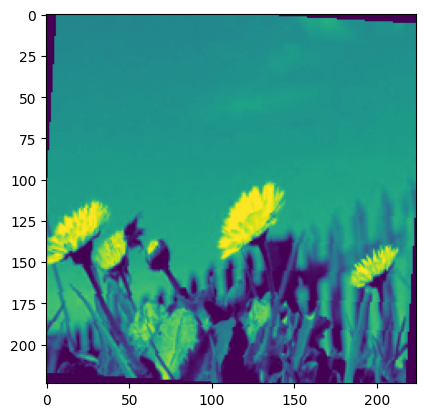

In [ ]:
# check immagine causale
import matplotlib.pyplot as plt
plt.imshow(train_dataset[2][0][0])
plt.show()

# Creazione modello

## Scelta

Considerata la grandezza ridotta del dataset, si è optato per il modello "efficientnet_b0"

In [ ]:
all_models = timm.list_models(pretrained=True)

In [ ]:
model = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=2
)

## Setup

Per ottimizzare il processo si è usata la tecnica del transfer learning, inizialmente congelando il backbone pre-addestrato e sbloccando solo il classificatore; successivamente sono stati sbloccati gli ultimi blocchi della rete per un fine-tuning parziale. Pertanto, l'ottimizzatore è stato attivato solo per i pesi modificabili.
E' stato inoltre definito un LR scheduler di tipo CosineAnnealingLR per ottimizzare la performance di minimizzazione gradiente ed evitare minimi locali.

In [ ]:
# setting pesi da tenere e pesi da addestrare
for param in model.parameters(): # congelo la parte di pesi relativa al feature extractor
    param.requires_grad = False

for param in model.classifier.parameters(): # lascio editabile la parte di pesi relativa al classificatore finale
    param.requires_grad = True

for param in model.blocks[-1].parameters():
    param.requires_grad = True

for param in model.blocks[-2].parameters():
    param.requires_grad = True

for param in model.conv_head.parameters():
    param.requires_grad = True

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

criterion = nn.CrossEntropyLoss(weight=class_weights)
criterion = criterion.to(device)
# definizione dell'ottimizzatore solo in base ai pesi che voglio aggiornare
backbone_params = []
classifier_params = []

for name, param in model.named_parameters():
    if param.requires_grad:
        if "classifier" in name:
            classifier_params.append(param)
        else:
            backbone_params.append(param)

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": 1e-5},
    {"params": classifier_params, "lr": 1e-4},
])
# definizione il learning rate scheduler
lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25, eta_min=0.000001)

model.to(device);

In [ ]:
# definizione EarlyStopping
class EarlyStopping:
  def __init__(self, patience=5, min_delta=0):
    self.patience = patience
    self.min_delta = min_delta
    self.counter = 0
    self.best_loss = float("inf")
    self.early_stop = False

  def __call__(self, val_loss):
    if val_loss < self.best_loss - self.min_delta: # se sto migliorando in termini di loss
      self.best_loss = val_loss
      self.counter = 0
    else: # se sto peggiorando in termini di loss
      self.counter += 1
      if self.counter >= self.patience:
        self.early_stop = True

class ModelCheckpoint:
  def __init__(self, filepath):
    self.output = filepath
    os.makedirs(self.output, exist_ok=True) # check: se la cartella è presente --> non da errore
    self.best_loss = float("inf")
    self.best_epoch = 0

  def __call__(self, val_loss, model, epoch) -> None:
    if val_loss < self.best_loss:
      self.best_loss = val_loss
      self.best_epoch = epoch
      torch.save(model.state_dict(), os.path.join(self.output, f"model.pth"))
      print(f"Model saved at epoch {epoch} with val_loss={val_loss:.4}")
    else:
      print(f"Validation loss did not improve from={self.best_loss:.4}")

In [ ]:
# definizione metodo per avvio train sui vari batch
def train_epoch(
    model: nn.Module,
    train_loader: DataLoader,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
    device: str = "cpu",
    log_every_n_iter: int = 10
) -> Tuple[float, float]:

  model.train()
  running_loss = 0.0
  total = 0
  correct = 0
  print(f"Epoch: {epoch}")
  for i, batch in enumerate(train_loader, 0):
    x, labels = [el for el in batch]
    x = x.to(device)
    labels = labels.to(device)
    optimizer.zero_grad()
    logits = model(x)
    loss = criterion(logits, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
    epoch_loss = running_loss / len(train_loader)
    _, preds = torch.max(logits.data, 1)
    total += labels.size(0)
    correct += (preds == labels).sum().item()
    if (i+1) % log_every_n_iter == 0:    # Print every log_every_n_iter mini-batches
        print(f"> iter [{i+1}/{len(train_loader)}] - train_loss={epoch_loss/log_every_n_iter:.4f} - LR={optimizer.param_groups[0]['lr']:.10f}")
        running_loss = 0.0

  epoch_acc = 100*correct / total

  return   epoch_loss, epoch_acc

In [ ]:
# definizione metodo per validazione modello sui vari batch
def val_epoch(
    model: nn.Module,
    val_loader: DataLoader,
    criterion: nn.Module,
    device: str = "cpu",
) -> Tuple[float, float]:
    # test loop
  model.eval()
  running_loss = []
  total, correct = 0, 0
  with torch.no_grad():
    for batch in val_loader:
      x, labels = [el.to(device) for el in batch]
      logits = model(x)
      loss = criterion(logits, labels)
      running_loss.append(loss.item())
      _, preds = torch.max(logits.data, 1)
      total += labels.size(0)
      correct += (preds == labels).sum().item()
  epoch_loss = sum(running_loss) / len(val_loader)
  epoch_acc = 100*correct / total

  return   epoch_loss, epoch_acc

In [ ]:
# definizione metodo per test finale con calcolo e restituzione di epoch_loss, epoch_acc, precision, recall, f1
def test_epoch(
    model: nn.Module,
    test_loader: DataLoader,
    criterion: nn.Module,
    device: str = "cpu",
) -> Tuple[float, float, float, float, float]:

    model.eval()

    running_loss = []

    total, correct = 0, 0

    # inizializzazione per le metriche
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            x, labels = [el.to(device) for el in batch]

            logits = model(x)
            loss = criterion(logits, labels)
            running_loss.append(loss.item())

            _, preds = torch.max(logits, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            # salvataggio per le metriche
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    # concatena tutto
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    epoch_loss = sum(running_loss) / len(test_loader)
    epoch_acc = 100 * correct / total


    # PRECISION / RECALL / F1
    tp = ((all_preds == all_labels) & (all_labels == all_preds)).sum().item()
    precision = precision_score(all_labels, all_preds, average="macro")
    recall = recall_score(all_labels, all_preds, average="macro")
    f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_acc, precision, recall, f1

# Model training

Addestramento modello, 25 epoche, a seconda del setting do_train: se true esso viene addestrato, se false viene bypassato l'addestramento e viene chiesto di caricare il modello da locale.

In [ ]:
if do_train:
  num_epochs = 25
  log_every_n_iter = int(0.1*(len(train_loader)))
  early_stopping = EarlyStopping(patience=3, min_delta=0.0001)
  model_checkpoint = ModelCheckpoint("checkpoints")

  train_losses_vector = []
  val_losses_vector = []
  train_accs_vector = []
  val_accs_vector = []

  for epoch in range(num_epochs):
    print(f"Epoch: [{epoch+1}/{num_epochs}]")
    print(f"Train report:")

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device, log_every_n_iter)
    val_loss, val_acc = val_epoch(model, val_loader, criterion, device)

    train_losses_vector.append(train_loss)
    val_losses_vector.append(val_loss)

    train_accs_vector.append(train_acc)
    val_accs_vector.append(val_acc)

    print(f"Val report:")
    print(f"> Val loss={val_loss:.4f} - val_accuracy={val_acc:.4f}")

    lr_scheduler.step()
    early_stopping(val_loss)
    if early_stopping.early_stop:
      print("Early stopping")
      break
    model_checkpoint(val_loss, model, epoch)

  print(f"Finished training at epoch {epoch+1}")
else:
  if exists("/content/checkpoints/model.pth"):
    model.load_state_dict(torch.load("/content/checkpoints/model.pth", map_location=device))
  else:
    from google.colab import files
    uploaded = files.upload()

In [ ]:
# stampaggio metriche "medie"
test_loss, test_acc, precision, recall, f1 = test_epoch(model, test_loader, criterion, device)
print(f"Test report:")
print(f"> Test loss={test_loss:.4f} - Test accuracy={test_acc:.4f}")
print(f"> Precision={precision:.4f} - Recall={recall:.4f} - F1={f1:.4f}")

Test report:
> Test loss=0.4169 - Test accuracy=91.7582
> Precision=0.9143 - Recall=0.9182 - F1=0.9160


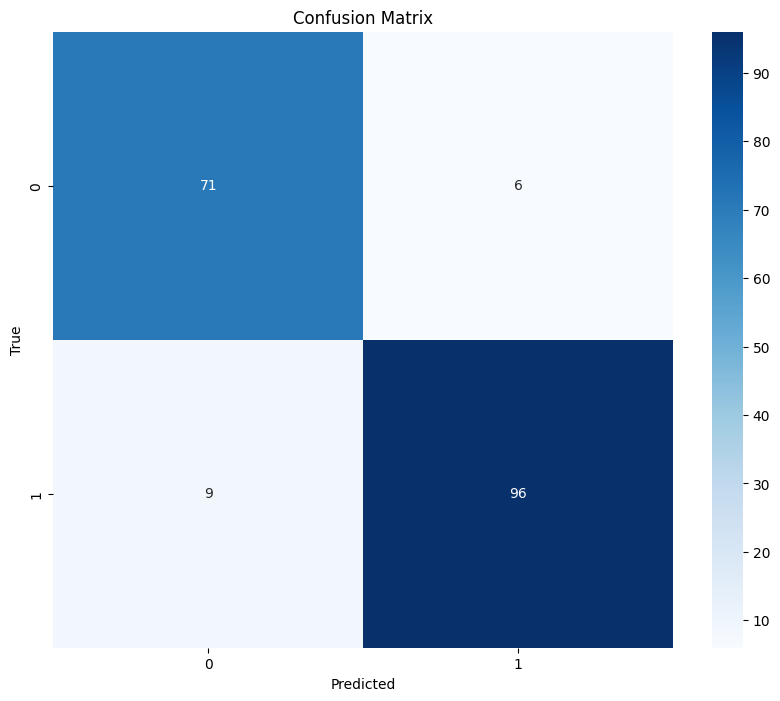


Classification report:

              precision    recall  f1-score   support

           0       0.89      0.92      0.90        77
           1       0.94      0.91      0.93       105

    accuracy                           0.92       182
   macro avg       0.91      0.92      0.92       182
weighted avg       0.92      0.92      0.92       182



In [ ]:
# Confusion matrix
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for x, labels in test_loader:
        x = x.to(device)
        labels = labels.to(device)

        logits = model(x)
        preds = torch.argmax(logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# calcolo f1 PER ciascuna classe
print("\nClassification report:\n")
print(classification_report(y_true, y_pred))

In [ ]:
if do_train:
  torch.save(model.state_dict(), f"model_w_accuracy={test_acc:.2f}.pth")
  files.download(f"model_w_accuracy={test_acc:.2f}.pth")

Predicted class is 'daisy' with prob=0.9136 - Ground Truth class is dandelion
106


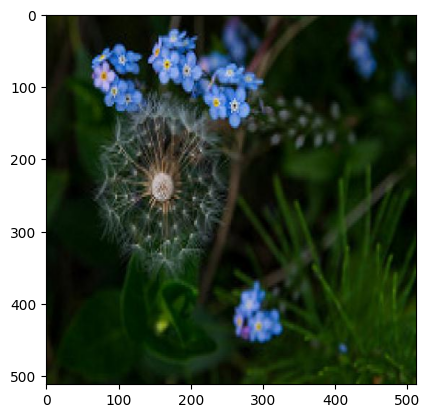

In [ ]:
# test per verificare non-corrispondenza delle classi predette con quelle vere sul test set
gt_label = 0
pred_label_name = ""

while list(LABELS_MAP)[gt_label] == pred_label_name or pred_label_name == "":
  idx = random.randint(0, len(test_dataset)-1)
  img, target = test_dataset[idx]
  gt_label = test_dataset.labels[idx]
  image_path = test_dataset.images[idx]
  x = img.unsqueeze(0)



  with torch.no_grad():
    model.eval()
    logits = model(x.to(device))
    probs = F.softmax(logits, 1)
    pred_prob, pred_class = torch.max(probs.data, 1)


  image = Image.open(image_path)

  pred_label_name = list(LABELS_MAP)[pred_class[0]]

print(f"Predicted class is '{pred_label_name}' with prob={pred_prob[0]:.4f} - Ground Truth class is {list(LABELS_MAP)[gt_label]}")
plt.imshow(image);
print(idx)


In [ ]:
if do_train:
  epochs = range(len(train_losses_vector))

  plt.figure(figsize=(12,5))

  # LOSS
  plt.subplot(1,2,1)
  plt.plot(epochs, train_losses_vector, label="Train Loss")
  plt.plot(epochs, val_losses_vector, label="Val Loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend()

  # ACCURACY
  plt.subplot(1,2,2)
  plt.plot(epochs, train_accs_vector, label="Train Acc")
  plt.plot(epochs, val_accs_vector, label="Val Acc")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend()

  plt.show()

# Conclusioni

Il training del modello scelto ha portato notevoli risultati in termini di F1 Macro (utile proprio per via dello sbilanciamento del dataset), precision e accuracy, se commisurati alla scarsità delle immagini presenti nel dataset, per sopperire alla quale è stata usata la tecnica Data Augmentation. Per rendere ancora più performante il modello, è stato necessario addestrare non solo il suo classificatore, ma anche gli ultimi 2 blochi della rete in aggiunta al conv_head.
Il learning rate scheduler ha contribuito a stabilizzare l’addestramento, mentre l’early stopping ha aiutato a contenere l’overfitting. La metrica obiettivo del progetto è il macro F1, che ha senso in quanto il dataset è sbilanciato. infatti, la macro F1 "pesa" in modo uguale entrambe le classi.